# Thời gian và chi phí theo từng stage của một query

Nhập `QUERY` rồi chạy toàn bộ notebook (Run All). Với mỗi hệ (No BF, BF + S3, BF + NFS), notebook in bảng theo từng stage gồm thời gian và chi phí **thực đo** so với **model**.

Dữ liệu lấy từ `report.json` do `cost_model_batch.py` sinh ra.

* `T_fn` (đo): max qua các function của (`t_total` + `disp`); `T_wall` (đo): thời gian thật của stage (gồm chờ hàng đợi `max_parallel`); `T_model`: $d_v$ của model
* `C` tính bằng µ$ (10⁻⁶ USD) = GET/PUT + GB-s + invocation + lưu trữ trung gian
* `★` = stage nằm trên đường găng (critical path) thực đo, `☆` = trên đường găng của model
* `err = (model − đo) / đo`

In [1]:
QUERY   = "q20"                      # q2 … q21
REPORT  = "cost-report/tpch100-v5"      # hoặc "cost-report/tpch100-v2"
RUN     = "median"                   # "median" = run có T đo ở giữa, hoặc 1 / 2 / 3
SYSTEMS = ["base", "s3", "nfs"]      # base = No BF

In [2]:
import os, json, glob, statistics
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

LABEL = {"base": "No BF", "s3": "BF + S3 shuffle", "nfs": "BF + NFS shuffle"}
MEAS, MODEL = "#2a78d6", "#eb6834"
ROOT = ".."   # report.json lưu đường dẫn history/... tính từ thư mục gốc repo


def load(query, system, run):
    """Trả về (run dict trong report.json, nhãn run). No BF lấy từ cặp s3-run<i>."""
    prefix = "s3" if system == "base" else system
    side = "nobf" if system == "base" else "bf"
    paths = sorted(glob.glob(os.path.join(REPORT, query, f"{prefix}-run*", "report.json")))
    if not paths:
        raise FileNotFoundError(f"không có report cho {query}/{prefix} trong {REPORT}")
    reps = {int(p.split("-run")[-1].split(os.sep)[0]): json.load(open(p))["runs"][side] for p in paths}
    if run == "median":
        T = {i: r["totals"]["T_meas"] for i, r in reps.items()}
        i = min(T, key=lambda k: (T[k] != statistics.median_low(T.values()), k))
    else:
        i = int(run)
    return reps[i], f"run {i}/{len(reps)}"


def critical_path(steps, dur):
    eft, prev = {}, {}
    for s in steps:
        ds = [d for d in s["deps"] if d in eft]
        best = max(ds, key=lambda d: eft[d]) if ds else None
        eft[s["name"]] = (eft[best] if best else 0.0) + dur[s["name"]]
        prev[s["name"]] = best
    n, path = max(eft, key=eft.get), set()
    while n:
        path.add(n)
        n = prev[n]
    return path


def stage_table(run):
    st = pd.DataFrame(run["stages"]).set_index("stage")
    dag_path = os.path.join(ROOT, run["folder"], "cost-dag.json")
    if os.path.exists(dag_path):   # cần thư mục history/ để biết đường găng; thiếu thì bỏ cột CP
        steps = [s for s in json.load(open(dag_path))["steps"] if s["name"] in st.index]
        cp_meas = critical_path(steps, st["meas_d_wall"].to_dict())
        cp_model = critical_path(steps, st["model_d"].to_dict())
    else:
        cp_meas = cp_model = set()
    t = pd.DataFrame({
        "func": st["func"], "p": st["p"], "cold": st["cold"],
        "CP": ["★" * (n in cp_meas) + "☆" * (n in cp_model) for n in st.index],
        "T_fn": st["meas_d_fn"], "T_wall": st["meas_d_wall"], "T_model": st["model_d"],
        "err_T_%": 100 * (st["model_d"] / st["meas_d_fn"] - 1),
        "C_meas_µ$": st["meas_C"] * 1e6, "C_model_µ$": st["model_C"] * 1e6,
        "err_C_%": 100 * (st["model_C"] / st["meas_C"] - 1),
        "C_share_%": 100 * st["meas_C"] / st["meas_C"].sum(),
    })
    tot = run["totals"]
    t.loc["TOTAL (query)"] = {
        "func": "", "p": st["p"].sum(), "cold": st["cold"].sum(), "CP": "",
        "T_fn": tot["T_cp_fn"], "T_wall": tot["T_meas"], "T_model": tot["T_model"],
        "err_T_%": tot["err_T_%"],
        "C_meas_µ$": tot["C_meas"] * 1e6, "C_model_µ$": tot["C_model"] * 1e6,
        "err_C_%": tot["err_C_%"], "C_share_%": 100.0,
    }
    return t


def phase_table(run):
    """Chi tiết các pha của một function trung bình: đọc / tính toán / ghi / dispatch."""
    st = pd.DataFrame(run["stages"]).set_index("stage")
    return pd.DataFrame({
        "read": st["meas_t_read"], "read_model": st["model_t_in"],
        "comp": st["meas_t_comp"], "comp_model": st["model_t_c"], "  ↳ bf_model": st["model_t_bf"],
        "write": st["meas_t_write"], "write_model": st["model_t_out"],
        "disp": st["meas_disp"], "disp_model": st["model_disp"],
        "CI_µ$": st["meas_CI"] * 1e6, "CC_µ$": st["meas_CC"] * 1e6, "CO_µ$": st["meas_CO"] * 1e6,
    })


def show(t):
    fmt = {c: "{:.2f}" for c in ("T_fn", "T_wall", "T_model")}
    fmt.update({c: "{:+.0f}" for c in ("err_T_%", "err_C_%")})
    fmt.update({c: "{:,.1f}" for c in ("C_meas_µ$", "C_model_µ$")})
    fmt["C_share_%"] = "{:.1f}"
    err = ["err_T_%", "err_C_%"]
    return (t.style.format(fmt, na_rep="–")
            .background_gradient(cmap="RdBu_r", vmin=-100, vmax=100, subset=pd.IndexSlice[t.index[:-1], err])
            .bar(subset=pd.IndexSlice[t.index[:-1], ["C_share_%"]], color="#c9dcf3", vmin=0, vmax=100)
            .set_properties(subset=pd.IndexSlice[["TOTAL (query)"], :], **{"font-weight": "bold"}))


def plot(t, title):
    s = t.drop(index="TOTAL (query)").iloc[::-1]
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 0.32 * len(s) + 1.2), sharey=True)
    y, h = range(len(s)), 0.38
    for ax, (m, mo, unit) in zip((a1, a2), (("T_fn", "T_model", "s"), ("C_meas_µ$", "C_model_µ$", "µ$"))):
        ax.barh([i + h / 2 for i in y], s[m], h, color=MEAS, label="đo")
        ax.barh([i - h / 2 for i in y], s[mo], h, color=MODEL, label="model")
        ax.set_xlabel(unit)
        ax.grid(axis="x", color="#e4e3df", lw=0.6)
        ax.spines[["top", "right"]].set_visible(False)
    a1.set_yticks(list(y), s.index, fontsize=8)
    a1.set_title("Thời gian stage", loc="left", fontsize=9)
    a2.set_title("Chi phí stage", loc="left", fontsize=9)
    a2.legend(loc="lower right", frameon=False, fontsize=8)
    fig.suptitle(title, x=0.01, ha="left", fontsize=10)
    fig.tight_layout()
    plt.show()

## Bảng theo stage

### Q20 — No BF  (run 9/15)
T đo **35.94 s**, model 30.91 s (-14%) · C đo **79,277 µ$**, model 62,074 µ$ (-22%)  
`history/q20/20261002-00291790900998--starling-base`

,func,p,cold,CP,T_fn,T_wall,T_model,err_T_%,C_meas_µ$,C_model_µ$,err_C_%,C_share_%
stage,,,,,,,,,,,,
step1-nation,scan,1,0,,0.06,0.06,0.05,-16,8.4,8.5,+2,0.0
step1-nation--combine,aggregate,1,0,,0.06,0.06,0.06,+1,7.8,8.3,+6,0.0
step2-supplier,scan,10,0,,0.15,0.16,0.13,-18,120.7,118.6,-2,0.2
step2-supplier--combine,aggregate,1,0,,0.51,0.51,0.85,+67,44.7,57.7,+29,0.1
step3-join-nation-supplier,broadcast_join,1,0,,0.20,0.20,0.33,+65,27.7,32.5,+18,0.0
step3-join-nation-supplier--combine,aggregate,1,0,,0.08,0.08,0.09,+15,9.3,10.1,+9,0.0
step4-part,scan,10,0,,0.49,0.49,0.44,-9,222.6,224.2,+1,0.3
step4-part--combine,aggregate,1,0,,0.12,0.12,0.10,-11,19.6,20.7,+6,0.0
step5-lineitem,scan,150,0,,3.41,5.11,5.44,+59,"12,237.0","10,889.0",-11,15.4


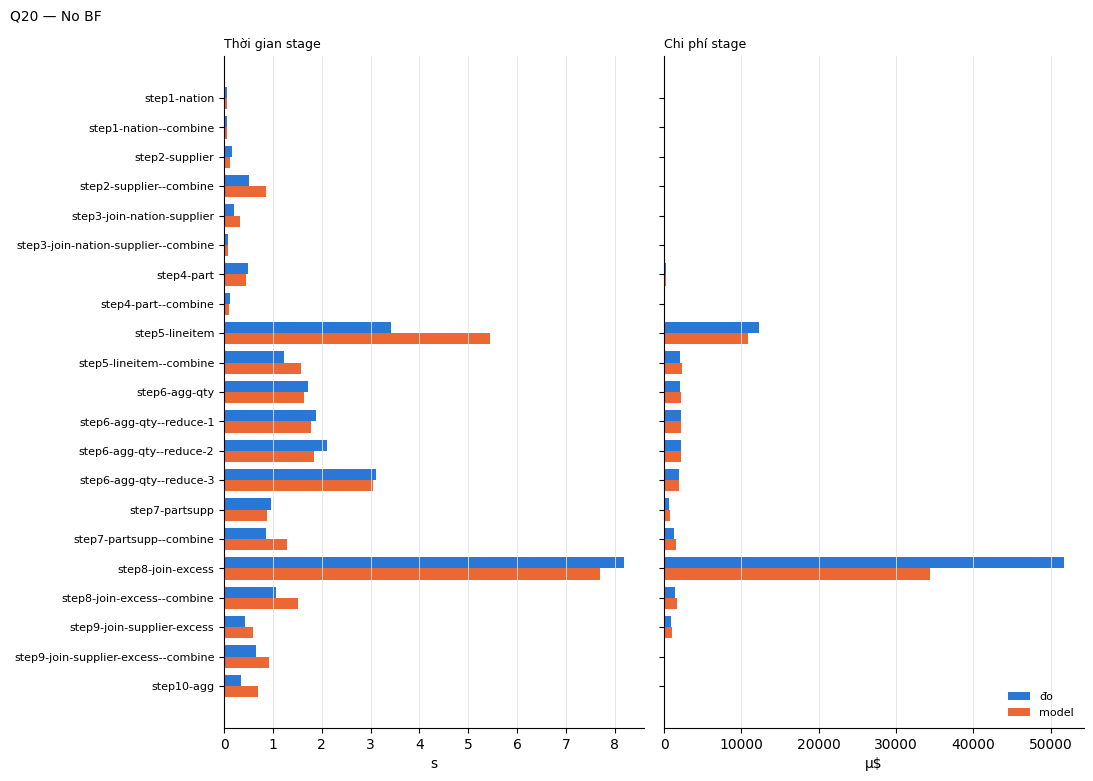

### Q20 — BF + S3 shuffle  (run 8/15)
T đo **10.31 s**, model 11.48 s (+11%) · C đo **13,895 µ$**, model 13,864 µ$ (-0%)  
`history/q20/20261002-02571790909833--bloomfaas-s3-bloomfaas`

,func,p,cold,CP,T_fn,T_wall,T_model,err_T_%,C_meas_µ$,C_model_µ$,err_C_%,C_share_%
stage,,,,,,,,,,,,
step1-nation,scan,1,0,,0.06,0.06,0.05,-9,8.2,8.5,+5,0.1
step1-nation--combine,aggregate,1,0,,0.07,0.07,0.06,-19,8.3,8.3,-1,0.1
step1-nation--mergebf,merge_bf,1,0,,0.03,0.03,0.05,+116,0.8,2.0,+159,0.0
step2-supplier,scan,10,0,,0.11,0.11,0.11,+2,102.5,112.9,+10,0.7
step2-supplier--combine,aggregate,1,0,,0.16,0.16,0.16,-2,32.8,34.4,+5,0.2
step2-supplier--mergebf,merge_bf,1,0,,0.03,0.04,0.05,+60,1.0,2.0,+98,0.0
step3-join-nation-supplier,broadcast_join,1,0,,0.09,0.09,0.07,-21,11.3,11.1,-1,0.1
step3-join-nation-supplier--combine,aggregate,1,0,,0.08,0.08,0.09,+12,9.4,10.1,+8,0.1
step4-part,scan,10,0,,0.43,0.43,0.44,+3,200.5,224.2,+12,1.4


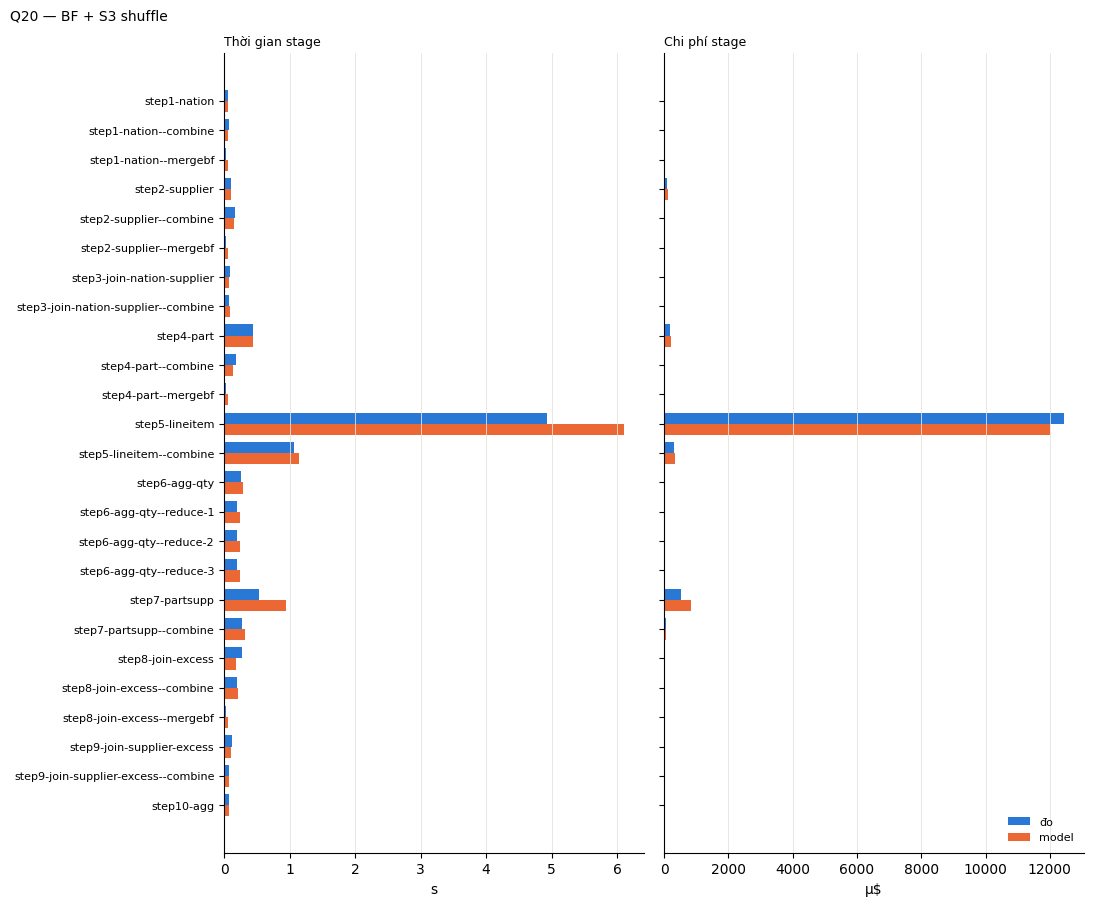

### Q20 — BF + NFS shuffle  (run 15/15)
T đo **9.10 s**, model 10.39 s (+14%) · C đo **11,604 µ$**, model 12,441 µ$ (+7%)  
`history/q20/20261002-05271790918859--bloomfaas-nfs-bloomfaas`

,func,p,cold,CP,T_fn,T_wall,T_model,err_T_%,C_meas_µ$,C_model_µ$,err_C_%,C_share_%
stage,,,,,,,,,,,,
step1-nation,scan,1,0,,0.05,0.05,0.05,+11,2.9,3.5,+21,0.0
step1-nation--combine,aggregate,1,0,,0.05,0.05,0.05,+13,1.6,2.0,+27,0.0
step1-nation--mergebf,merge_bf,1,0,,0.02,0.02,0.05,+135,0.8,2.0,+163,0.0
step2-supplier,scan,10,0,,0.11,0.11,0.11,+1,53.7,62.8,+17,0.5
step2-supplier--combine,aggregate,1,0,,0.21,0.21,0.23,+11,6.9,7.9,+15,0.1
step2-supplier--mergebf,merge_bf,1,0,,0.03,0.03,0.05,+101,0.8,2.0,+148,0.0
step3-join-nation-supplier,broadcast_join,1,0,,0.06,0.06,0.05,-9,1.9,2.0,+5,0.0
step3-join-nation-supplier--combine,aggregate,1,0,,0.05,0.05,0.08,+61,1.5,2.7,+78,0.0
step4-part,scan,10,0,,0.42,0.43,0.45,+6,151.4,176.4,+16,1.3


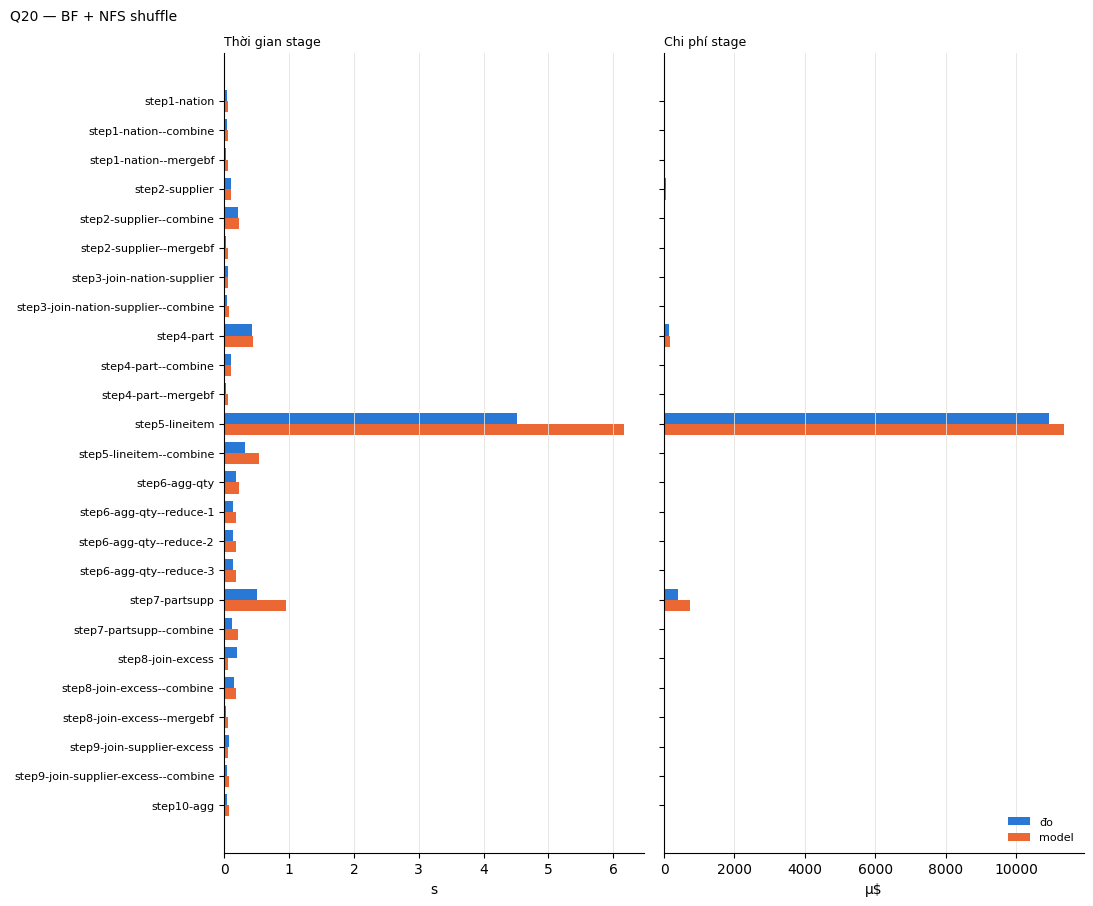

In [3]:
tables = {}
for sysname in SYSTEMS:
    run, tag = load(QUERY, sysname, RUN)
    t = tables[sysname] = stage_table(run)
    tot = run["totals"]
    display(Markdown(f"### {QUERY.upper()} — {LABEL[sysname]}  ({tag})\n"
                     f"T đo **{tot['T_meas']:.2f} s**, model {tot['T_model']:.2f} s ({tot['err_T_%']:+.0f}%) · "
                     f"C đo **{tot['C_meas']*1e6:,.0f} µ$**, model {tot['C_model']*1e6:,.0f} µ$ ({tot['err_C_%']:+.0f}%)  \n"
                     f"`{run['folder']}`"))
    display(show(t))
    plot(t, f"{QUERY.upper()} — {LABEL[sysname]}")

## Chi tiết các pha (thời gian trung bình mỗi function, s) và thành phần chi phí đo được

In [4]:
for sysname in SYSTEMS:
    run, tag = load(QUERY, sysname, RUN)
    display(Markdown(f"### {QUERY.upper()} — {LABEL[sysname]}  ({tag})"))
    display(phase_table(run).style.format("{:.3f}", subset=pd.IndexSlice[:, ["read", "read_model", "comp", "comp_model", "  ↳ bf_model", "write", "write_model", "disp", "disp_model"]])
            .format("{:,.1f}", subset=pd.IndexSlice[:, ["CI_µ$", "CC_µ$", "CO_µ$"]]))

### Q20 — No BF  (run 9/15)

,read,read_model,comp,comp_model,↳ bf_model,write,write_model,disp,disp_model,CI_µ$,CC_µ$,CO_µ$
stage,,,,,,,,,,,,
step1-nation,0.011,0.000,0.022,0.000,0.000,0.015,0.000,0.014,0.052,1.6,1.8,5.0
step1-nation--combine,0.000,0.000,0.023,0.003,0.000,0.018,0.000,0.014,0.052,1.2,1.6,5.0
step2-supplier,0.040,0.032,0.065,0.015,0.000,0.029,0.029,0.013,0.052,24.0,46.7,50.0
step2-supplier--combine,0.000,0.000,0.331,0.620,0.000,0.135,0.182,0.047,0.052,24.0,15.7,5.0
step3-join-nation-supplier,0.000,0.000,0.166,0.269,0.000,0.016,0.007,0.017,0.052,16.4,6.3,5.0
step3-join-nation-supplier--combine,0.000,0.000,0.045,0.028,0.000,0.018,0.007,0.014,0.052,2.0,2.3,5.0
step4-part,0.390,0.269,0.041,0.122,0.000,0.009,0.001,0.013,0.052,24.0,148.6,50.0
step4-part--combine,0.000,0.000,0.055,0.048,0.000,0.017,0.005,0.046,0.052,12.0,2.6,5.0
step5-lineitem,1.666,1.398,0.121,0.182,0.000,0.295,0.180,0.055,0.052,"1,048.0","10,438.8",750.2


### Q20 — BF + S3 shuffle  (run 8/15)

,read,read_model,comp,comp_model,↳ bf_model,write,write_model,disp,disp_model,CI_µ$,CC_µ$,CO_µ$
stage,,,,,,,,,,,,
step1-nation,0.008,0.000,0.022,0.000,0.000,0.011,0.000,0.016,0.052,1.6,1.6,5.0
step1-nation--combine,0.000,0.000,0.042,0.004,0.001,0.016,0.000,0.012,0.052,1.2,2.1,5.0
step1-nation--mergebf,0.001,0.001,0.015,0.000,0.000,0.001,0.001,0.008,0.052,0.0,0.8,0.0
step2-supplier,0.032,0.032,0.037,0.025,0.011,0.011,0.001,0.013,0.052,24.0,28.5,50.0
step2-supplier--combine,0.000,0.000,0.090,0.097,0.005,0.018,0.007,0.052,0.052,24.0,3.8,5.0
step2-supplier--mergebf,0.001,0.001,0.021,0.000,0.000,0.003,0.001,0.009,0.052,0.0,1.0,0.0
step3-join-nation-supplier,0.000,0.000,0.056,0.011,0.000,0.017,0.007,0.015,0.052,3.6,2.7,5.0
step3-join-nation-supplier--combine,0.000,0.000,0.048,0.028,0.000,0.016,0.007,0.013,0.052,2.0,2.4,5.0
step4-part,0.327,0.269,0.036,0.122,0.000,0.011,0.001,0.013,0.052,24.0,126.5,50.0


### Q20 — BF + NFS shuffle  (run 15/15)

,read,read_model,comp,comp_model,↳ bf_model,write,write_model,disp,disp_model,CI_µ$,CC_µ$,CO_µ$
stage,,,,,,,,,,,,
step1-nation,0.009,0.000,0.025,0.000,0.000,0.000,0.000,0.013,0.052,1.6,1.3,0.0
step1-nation--combine,0.000,0.000,0.042,0.002,0.001,0.000,0.000,0.006,0.052,0.0,1.6,0.0
step1-nation--mergebf,0.001,0.001,0.015,0.000,0.000,0.001,0.001,0.006,0.052,0.0,0.8,0.0
step2-supplier,0.035,0.032,0.048,0.026,0.011,0.000,0.000,0.012,0.052,24.0,29.7,0.0
step2-supplier--combine,0.000,0.000,0.200,0.179,0.025,0.000,0.000,0.009,0.052,0.0,6.9,0.0
step2-supplier--mergebf,0.001,0.001,0.015,0.000,0.000,0.003,0.001,0.009,0.052,0.0,0.8,0.0
step3-join-nation-supplier,0.000,0.000,0.052,0.003,0.000,0.000,0.000,0.008,0.052,0.0,1.9,0.0
step3-join-nation-supplier--combine,0.000,0.000,0.040,0.024,0.000,0.000,0.000,0.007,0.052,0.0,1.5,0.0
step4-part,0.333,0.269,0.043,0.130,0.000,0.000,0.000,0.014,0.052,24.0,127.4,0.0


## So sánh tổng giữa các hệ

In [5]:
pd.DataFrame({LABEL[s]: t.loc["TOTAL (query)", ["T_wall", "T_model", "err_T_%", "C_meas_µ$", "C_model_µ$", "err_C_%"]]
              for s, t in tables.items()}).T.astype(float).round(2)

,T_wall,T_model,err_T_%,C_meas_µ$,C_model_µ$,err_C_%
No BF,35.94,30.91,-13.98,79276.94,62073.53,-21.70
BF + S3 shuffle,10.31,11.48,11.28,13894.92,13864.26,-0.22
BF + NFS shuffle,9.10,10.39,14.15,11604.14,12440.59,7.21
